## **Indian Pincode Boundary Visualization using GeoPandas**

# Indian Pincode Boundary Mapping

This notebook works with Indian pincode boundary data and pincode attribute data.

The workflow includes:

- Loading pincode boundary polygons
- Merging administrative information using pincode
- State-wise visualization
- District-wise visualization
- Exporting processed GIS data
- Creating indexed pincode maps for districts

In [1]:
import os
from google.colab import files
import geopandas as gpd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.patheffects as pe

Please download the following files before running this notebook:

### Required Files

1. **INDIAN_PINCODE_BOUNDARY.geojson**
   - Download Link: https://drive.google.com/file/d/1dLpsz5_6GDONggo_1ANOC5BEPj21rLc1/view?usp=sharing

2. **india_pincode_lat_long.csv**
   - Download Link: https://drive.google.com/file/d/1EngXrLaRhm7LmDmpSzsWklt1GcRxtiC_/view?usp=sharing

In [2]:
required_files = [
    "INDIAN_PINCODE_BOUNDARY.geojson",
    "india_pincode_lat_long.csv"
]

missing = [
    f for f in required_files
    if f not in os.listdir("/content")
]

if missing:
    print("Missing:", missing)
    files.upload()
else:
    print("Files already available.")

Files already available.


In [3]:
gdf = gpd.read_file(
    "/content/INDIAN_PINCODE_BOUNDARY.geojson"
)

pincode_coordinates = pd.read_csv(
    "/content/india_pincode_lat_long.csv",
    low_memory=False
)

print("GeoJSON Shape :", gdf.shape)
print("CSV Shape :", pincode_coordinates.shape)

GeoJSON Shape : (19312, 6)
CSV Shape : (157126, 9)


In [4]:
display(
    pd.DataFrame(
        [gdf.columns.tolist()]
    )
)

,0,1,2,3,4,5
0,Pincode,Office_Name,Division,Region,Circle,geometry


In [5]:
display(
    pd.DataFrame(
        [pincode_coordinates.columns.tolist()]
    )
)

,0,1,2,3,4,5,6,7,8
0,StateName,CircleName,District,DivisionName,RegionName,OfficeName,Pincode,Latitude,Longitude


In [6]:
gdf.head(5)

,Pincode,Office_Name,Division,Region,Circle,geometry
0,110001,New Delhi GPO,New Delhi GPO,,Delhi,"POLYGON ((77.18584 28.62087, 77.18645 28.62041..."
1,110002,Indraprastha HO,New Delhi Central,,Delhi,"POLYGON ((77.2494 28.60809, 77.25127 28.60278,..."
2,110003,Lodi Road HO,New Delhi South,,Delhi,"POLYGON ((77.22925 28.61031, 77.22845 28.60909..."
3,110004,Rashtrapati Bhawan SO,New Delhi Central,,Delhi,"POLYGON ((77.18584 28.62087, 77.18394 28.61828..."
4,110005,Karol Bagh SO,New Delhi Central,,Delhi,"POLYGON ((77.18258 28.66114, 77.18278 28.66011..."


In [7]:
pincode_coordinates.head(5)

,StateName,CircleName,District,DivisionName,RegionName,OfficeName,Pincode,Latitude,Longitude
0,ANDHRA PRADESH,Andhra Pradesh Circle,ANANTAPUR,Hindupur Division,Kurnool Region,Peddakotla B.O,515631,14.5689,77.85624
1,ANDHRA PRADESH,Andhra Pradesh Circle,ANANTAPUR,Hindupur Division,Kurnool Region,Pinnadhari B.O,515631,14.5281,77.857014
2,ANDHRA PRADESH,Andhra Pradesh Circle,ANANTAPUR,Hindupur Division,Kurnool Region,Yerraguntapalle B.O,515631,14.561111,77.85715
3,ANDHRA PRADESH,Andhra Pradesh Circle,ANANTAPUR,Hindupur Division,Kurnool Region,Obulareddipalli B.O,515581,14.2488,78.2588
4,ANDHRA PRADESH,Andhra Pradesh Circle,ANANTAPUR,Hindupur Division,Kurnool Region,Odulapalli B.O,515581,14.24555,78.2477


In [8]:
gdf["Pincode"] = pd.to_numeric(
    gdf["Pincode"],
    errors="coerce"
)

pincode_coordinates["Pincode"] = pd.to_numeric(
    pincode_coordinates["Pincode"],
    errors="coerce"
)

coords_unique = (
    pincode_coordinates
    .sort_values("Pincode")
    .drop_duplicates("Pincode")
)

map_gdf = gdf.merge(
    coords_unique,
    on="Pincode",
    how="left"
)

In [9]:
print("GeoJSON Rows :", len(gdf))
print("Merged Rows :", len(map_gdf))

GeoJSON Rows : 19312
Merged Rows : 19312


In [10]:
print(
    "StateName Filled:",
    map_gdf["StateName"].notna().sum()
)

print(
    "District Filled:",
    map_gdf["District"].notna().sum()
)

print(
    "Latitude Filled:",
    map_gdf["Latitude"].notna().sum()
)

StateName Filled: 19148
District Filled: 19148
Latitude Filled: 18276


In [11]:
display(
    pd.DataFrame(
        [map_gdf.columns.tolist()]
    )
)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Pincode,Office_Name,Division,Region,Circle,geometry,StateName,CircleName,District,DivisionName,RegionName,OfficeName,Latitude,Longitude


In [12]:
map_gdf.to_file(
    "/content/MERGED_INDIAN_PINCODE_BOUNDARY.gpkg",
    driver="GPKG"
)

**State Analysis**

In [13]:
states = sorted(
    map_gdf["StateName"]
    .dropna()
    .unique()
)

print("Available States:\n")

for state in states:
    print(state)

selected_state = input(
    "\nEnter State Name: "
).strip().upper()

state_map = map_gdf[
    map_gdf["StateName"]
    .str.upper()
    == selected_state
].copy()

print(
    f"\nRows Found: {len(state_map)}"
)

print(
    f"Pincodes: {state_map['Pincode'].nunique()}"
)

print(
    f"Districts: {state_map['District'].nunique()}"
)

Available States:

ANDAMAN AND NICOBAR ISLANDS
ANDHRA PRADESH
ARUNACHAL PRADESH
ASSAM
BIHAR
CHANDIGARH
CHHATTISGARH
DELHI
GOA
GUJARAT
HARYANA
HIMACHAL PRADESH
JAMMU AND KASHMIR
JHARKHAND
KARNATAKA
KERALA
LADAKH
LAKSHADWEEP
MADHYA PRADESH
MAHARASHTRA
MANIPUR
MEGHALAYA
MIZORAM
NAGALAND
ODISHA
PUDUCHERRY
PUNJAB
RAJASTHAN
SIKKIM
TAMIL NADU
TELANGANA
THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU
TRIPURA
UTTAR PRADESH
UTTARAKHAND
WEST BENGAL

Enter State Name: MAHARASHTRA

Rows Found: 1585
Pincodes: 1585
Districts: 36


**STATE MAP VISUALIZATION**

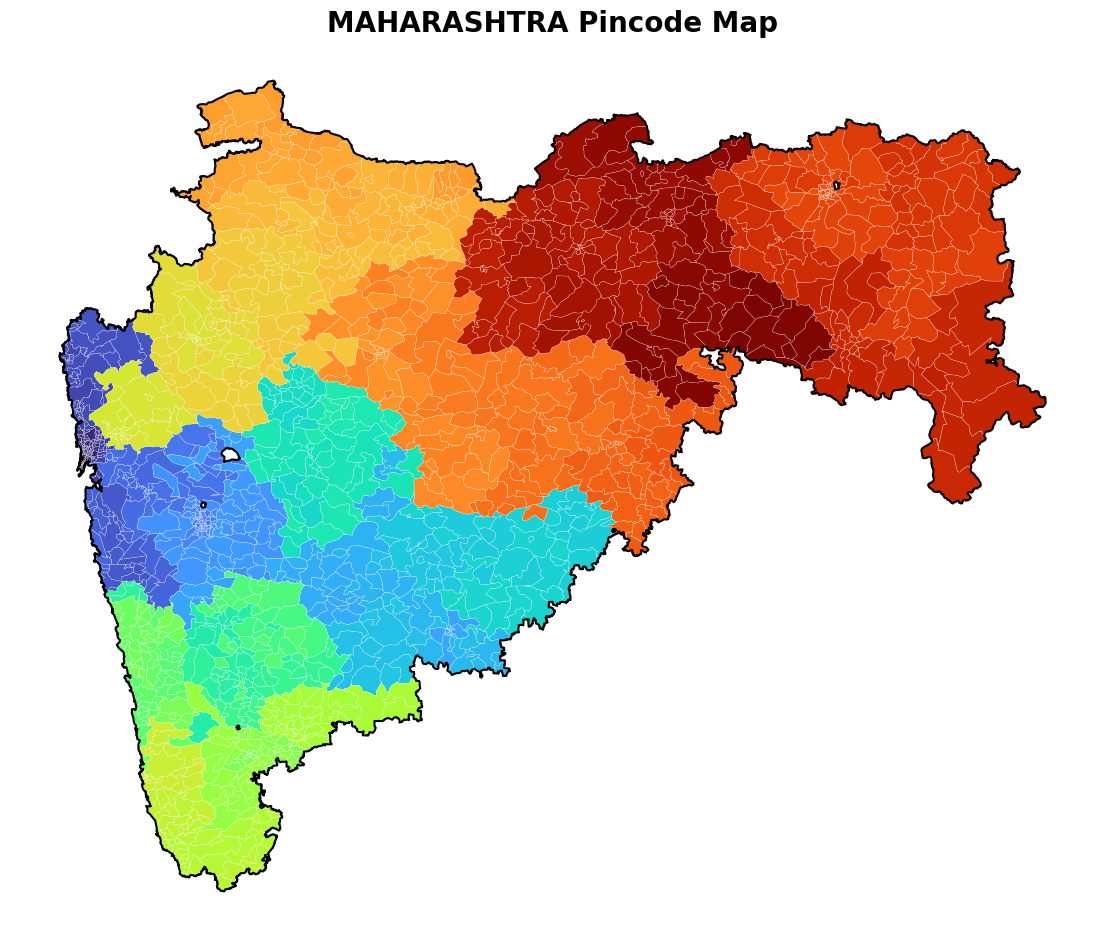

In [14]:
state_map["ColorID"] = np.arange(
    len(state_map)
)

state_boundary = state_map.dissolve()

fig, ax = plt.subplots(
    figsize=(14,14)
)

state_map.plot(
    column="ColorID",
    cmap="turbo",
    edgecolor="white",
    linewidth=0.15,
    ax=ax
)

state_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

ax.set_title(
    f"{selected_state} Pincode Map",
    fontsize=20,
    fontweight="bold"
)

ax.axis("off")

plt.show()

**State Export Data**

In [15]:
csv_name = (
    f"{selected_state}_"
    f"{state_map['Pincode'].nunique()}_Pincodes.csv"
)

state_export = state_map.drop(
    columns=["geometry"],
    errors="ignore"
)

state_export.to_csv(csv_name, index=False)
files.download(csv_name)

print("Saved:", csv_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: MAHARASHTRA_1585_Pincodes.csv


**District Analysis**

In [16]:
districts = sorted(
    state_map["District"]
    .dropna()
    .unique()
)

print(
    f"Total Districts: {len(districts)}\n"
)

for d in districts:
    print(d)

Total Districts: 36

AHMEDNAGAR
AKOLA
AMRAVATI
AURANGABAD
BEED
BHANDARA
BULDHANA
CHANDRAPUR
DHULE
GADCHIROLI
GONDIA
HINGOLI
JALGAON
JALNA
KOLHAPUR
LATUR
MUMBAI
MUMBAI SUBURBAN
NAGPUR
NANDED
NANDURBAR
NASHIK
OSMANABAD
PALGHAR
PARBHANI
PUNE
RAIGAD
RATNAGIRI
SANGLI
SATARA
SINDHUDURG
SOLAPUR
THANE
WARDHA
WASHIM
YAVATMAL


In [17]:
selected_district = input(
    "\nEnter District Name: "
).strip().upper()

district_map = map_gdf[
    map_gdf["District"]
    .astype(str)
    .str.upper()
    == selected_district
].copy()

print(
    f"\nRows Found: {len(district_map)}"
)

print(
    "State(s):",
    district_map["StateName"]
    .dropna()
    .unique()
)


Enter District Name: MUMBAI SUBURBAN

Rows Found: 56
State(s): ['MAHARASHTRA']


**DISTRICT MAP VISUALIZATION**

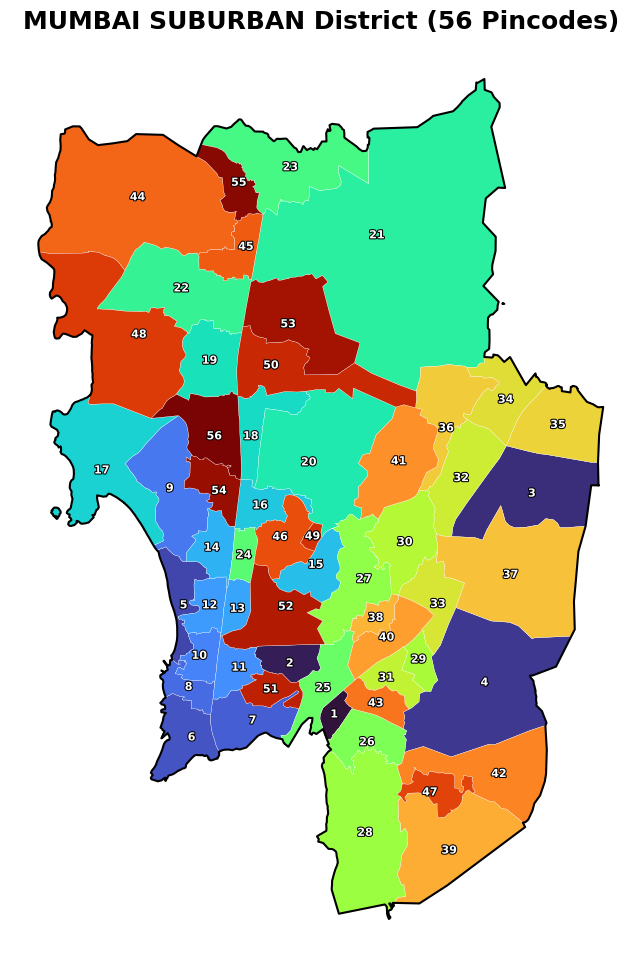

In [18]:
district_map["Index"] = range(
    1,
    len(district_map) + 1
)

district_map["ColorID"] = np.arange(
    len(district_map)
)

district_boundary = district_map.dissolve()

fig, ax = plt.subplots(
    figsize=(12,12)
)

district_map.plot(
    column="ColorID",
    cmap="turbo",
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

district_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

for _, row in district_map.iterrows():

    try:

        point = row.geometry.representative_point()

        txt = ax.text(
            point.x,
            point.y,
            str(row["Index"]),
            color="white",
            fontsize=8,
            fontweight="bold",
            ha="center",
            va="center"
        )

        txt.set_path_effects([
            pe.withStroke(
                linewidth=1.5,
                foreground="black"
            )
        ])

    except:
        pass

ax.set_title(
    f"{selected_district} District "
    f"({len(district_map)} Pincodes)",
    fontsize=18,
    fontweight="bold"
)

ax.axis("off")

plt.show()

**INDEX FOR ABOVE DISTRICT MAP**

In [19]:
index_table = district_map[
    [
        "Index",
        "Pincode",
        "Office_Name",
        "Division",
        "District",
        "StateName"
    ]
].sort_values("Index")

display(index_table)

,Index,Pincode,Office_Name,Division,District,StateName
5576,1,400024,Nehru Nagar SO,Mumbai City North East,MUMBAI SUBURBAN,MAHARASHTRA
5581,2,400029,Santacruz P and T Colony S.O,Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA
5589,3,400042,Bhandup East SO,Mumbai City North East,MUMBAI SUBURBAN,MAHARASHTRA
5590,4,400043,Shivaji Nagar SO Mumbai,Mumbai City North East,MUMBAI SUBURBAN,MAHARASHTRA
5591,5,400049,Juhu S.O,Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA
5592,6,400050,Bandra West S.O,Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA
5593,7,400051,Bandra(East) S.O,Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA
5594,8,400052,Khar Delivery S.O,Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA
5595,9,400053,Azad Nagar S.O (Mumbai),Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA
5596,10,400054,Santacruz(West) S.O,Mumbai City North,MUMBAI SUBURBAN,MAHARASHTRA


In [20]:
output_filename = f"{selected_state}_{selected_district}_pincode_index.csv"
index_table.to_csv(output_filename, index=False)
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>